This file predicts three categories: low, medium, and high. I reassigned all tickets labeled critical to high and all very_low tickets to low. I experimented with several models, including logistic regression, an SVM classifier, and XGBoost. Logistic regression performed the best, so the other models are included in the appendix.

In [6]:
from datasets import load_dataset
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")

df = dataset["train"].to_pandas()

# Initial Text Cleaning

In [7]:
# very_low ==> low, and high ==> critical
df.loc[df["priority"] == "very_low", "priority"] = "low"
df.loc[df["priority"] == "critical", "priority"] = "high"

# df.priority.value_counts()

In [8]:
import re

def clean_text(text):
    text = text.lower()
    
    # remove common greeting prefixes at start of message
    text = re.sub(r"^(dear\s+)?(customer\s+(support|service)\s*(team)?|support\s*team)[\s,:\-]*", "", text)

    # remove generic greetings, urls, signnatures, and whitespace
    text = re.sub(r"^(hello|hi|greetings)[\s,:\-]*", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"(best regards|kind regards|sincerely).*", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [9]:
# For english, change all df's to english

# Clean Subject and Body
df["body"] = df["body"].astype(str).apply(clean_text)
df["subject"] = df["subject"].astype(str).apply(clean_text)

# Concat subject and body into one "Text"
df["text"] = df["subject"] + " " + df["body"]

# Fill na with unknown
df["version"] = df["version"].fillna("unknown").astype(str)
# I doubt version would be a reasonable predictor but we shall see

# Combine all Tags into one
tag_cols = [f"tag_{i}" for i in range(1,9)]
df["all_tags"] = df[tag_cols].fillna("").agg(" ".join, axis=1)

In [24]:
# For english, change all df's to english

# Clean Subject and Body
df["body"] = df["body"].astype(str).apply(clean_text)
df["subject"] = df["subject"].astype(str).apply(clean_text)

# Concat subject and body into one "Text"
df["text"] = df["subject"] + " " + df["body"]

# Fill na with unknown
df["version"] = df["version"].fillna("unknown").astype(str)
# I doubt version would be a reasonable predictor but we shall see

# Combine all Tags into one
tag_cols = [f"tag_{i}" for i in range(1,9)]
df["all_tags"] = df[tag_cols].fillna("").agg(" ".join, axis=1)

## Train test split


In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["priority"])
y = df["priority"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

  
  
# 1) Vectorize Text

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=80000, # Changed
    ngram_range=(1,3),
    stop_words="english",
    sublinear_tf=True,
    max_df=0.85, # Added 
    norm=None,
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train["text"])
X_test_tfidf = tfidf.transform(X_test["text"])

# Logistic regression model serves as a simple baseline, with only the subject and body contributing.

# 2) Baseline Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # important if imbalance
    n_jobs=-1
)

log_reg.fit(X_train_tfidf, y_train)

/Users/kylebeedon/opt/miniconda3/envs/bertopic310/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post2)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
from sklearn.metrics import classification_report

y_pred = log_reg.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.78      0.79      0.78      4768
         low       0.76      0.73      0.75      2910
      medium       0.75      0.75      0.75      4675

    accuracy                           0.76     12353
   macro avg       0.76      0.76      0.76     12353
weighted avg       0.76      0.76      0.76     12353



# 3) Advanced Logistic Model

In [14]:
# Define text and categorical columns
text_col = "text"
cat_cols = ["type", "version", "all_tags","language"]

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=80000,
            ngram_range=(1,3),
            stop_words="english",
            sublinear_tf=True,
            max_df=0.85,
            norm=None,
            min_df=5
        ), text_col),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [16]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

In [17]:
pipeline.fit(X_train, y_train)


/Users/kylebeedon/opt/miniconda3/envs/bertopic310/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post2)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


,steps,"[('preprocessing', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
# Predict for X_test
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
# Logisitc 

              precision    recall  f1-score   support

        high       0.78      0.79      0.78      4768
         low       0.76      0.73      0.74      2910
      medium       0.75      0.75      0.75      4675

    accuracy                           0.76     12353
   macro avg       0.76      0.76      0.76     12353
weighted avg       0.76      0.76      0.76     12353



## Probabilies

In [19]:
# compute the probabilites for each of the labels

import numpy as np

y_probs = pipeline.predict_proba(X_test)
y_probs = np.round(y_probs, 4) 

from sklearn.preprocessing import label_binarize

classes = pipeline.classes_
y_test_bin = label_binarize(y_test, classes=classes)

In [20]:
probs = pd.DataFrame(y_probs, columns=pipeline.classes_)
probs["max_prob"] = probs[pipeline.classes_].max(axis=1)
probs["true_label"] = y_test.values
probs["pred_label"] = y_pred

probs.head()

,high,low,medium,max_prob,true_label,pred_label
0,0.9268,0.0154,0.0578,0.9268,medium,high
1,0.9420,0.0578,0.0001,0.9420,medium,high
2,1.0000,0.0000,0.0000,1.0000,high,high
3,0.0129,0.0943,0.8929,0.8929,medium,medium
4,0.0000,0.0000,1.0000,1.0000,medium,medium


### High confidence

In [16]:
# print(len(y_test))    # 12353
high_conf = probs[probs["max_prob"] >= 0.95]

In [17]:
acc_high_conf = (high_conf["true_label"] == high_conf["pred_label"]).mean() * 100
print(f"Accuracy when confidence ≥ 95%: {round(acc_high_conf, 4)}%")

Accuracy when confidence ≥ 95%: 84.5824%


In [18]:
print(f"{round((len(high_conf) / len(probs)) * 100,3)}% of all tickets in test set fall into high confidence bucket")

77.447% of all tickets in test set fall into high confidence bucket


## AUC/ROC


In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

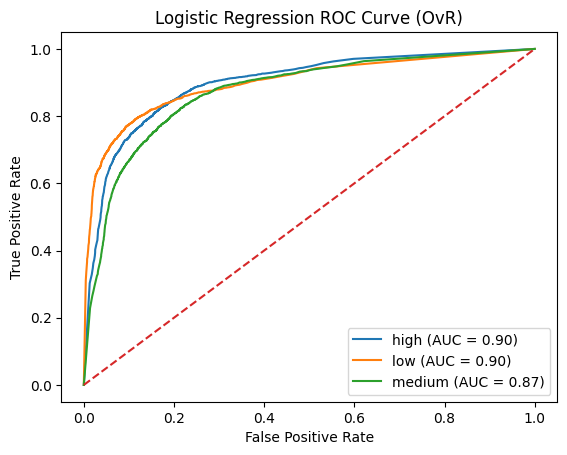

In [22]:
plt.figure()

for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve (OvR)")
plt.legend()
plt.show()

# Appendix

## Critical Tickets

In [42]:
import pandas as pd

# all common inflected forms of "kritisch"
words = r'\b(kritisch|kritische|kritischer|kritischem|kritischen|kritisches)\b'

crit = df[df.priority == "critical"].copy()

crit["has_keyword3"] = crit["body"].str.contains(words, case=False, regex=True)
count = crit["has_keyword3"].sum()

print(f"Some form of 'critical' is in {round(100 * (count/len(crit)), 3)}% of all critical tickets")

Some form of 'critical' is in 65.674% of all critical tickets


/var/folders/1t/7f8m5t153xd1mm3thdc46cq00000gn/T/ipykernel_76003/2702033503.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  crit["has_keyword3"] = crit["body"].str.contains(words, case=False, regex=True)


## False negative exploration

In [55]:
FN = len(eval_df[(eval_df.y_true == "high") & (eval_df.y_pred == "low")]) # False Negatives
FM = len(eval_df[(eval_df.y_true == "high") & (eval_df.y_pred == "medium")])
TP = len(eval_df[(eval_df.y_true == "high") & (eval_df.y_pred == "high")])

    
print(
    f"{round((FN / (FN + FM + TP))*100, 5)}% of high-priority tickets were misclassified as low priority."
)

6.45534% of high-priority tickets were misclassified as low priority.


## Missing counts

In [56]:
missing_counts = eval_df.isnull().sum()
print(missing_counts)

subject         0
body            0
answer       2668
type         2666
queue           0
language        0
version         0
tag_1        2666
tag_2        2677
tag_3        2718
tag_4        3589
tag_5        6919
tag_6        9685
tag_7       11154
tag_8       11859
text            0
all_tags        0
y_true          0
y_pred          0
correct         0
dtype: int64


# 4) XGBoost

In [ ]:
from xgboost import XGBClassifier

pipeline_xgb = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        num_class=5,
        eval_metric="mlogloss",
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=5,
        random_state=42
    ))
])

#### 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

#### 
pipeline_xgb.fit(X_train, y_train_enc)

### 
y_pred_enc = pipeline_xgb.predict(X_test)

# convert back to original labels for report
y_pred = le.inverse_transform(y_pred_enc)

print(classification_report(y_test, y_pred))

# 4) SVM network

In [ ]:
from sklearn.svm import LinearSVC

pipeline_svm = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", LinearSVC(
        class_weight="balanced",
        max_iter=5000
    ))
])

pipeline_svm.fit(X_train, y_train)

y_pred_svc = pipeline_svm.predict(X_test)
print(classification_report(y_test, y_pred_svc))
# SVM

## a) AUC/ROC Curves

from sklearn.preprocessing import label_binarize

classes = sorted(set(y_train))
y_test_bin = label_binarize(y_test, classes=classes)

y_scores = pipeline_svm.decision_function(X_test)

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (OvR)")
plt.legend()
plt.show()